In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

from tqdm import tqdm
import time

from xgboost.callback import TrainingCallback

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [2]:
df = pd.read_csv("Data/data_processed.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = df.drop(columns=["Class"])
y = df["Class"]

print(X.shape)
print(y.value_counts())

(283726, 30)
Class
0    283253
1       473
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(226980, 30)
(56746, 30)


In [5]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

scale_pos_weight

np.float64(599.4761904761905)

In [6]:
model = XGBClassifier(
    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=300,
    learning_rate=0.05,

    max_depth=6,
    min_child_weight=2,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    tree_method="hist"
)

In [ ]:
class TQDMCallback(TrainingCallback):

    def __init__(self, n_estimators):
        self.pbar = tqdm(
            total=n_estimators,
            desc="Training XGBoost"
        )

    def after_iteration(
        self,
        model,
        epoch,
        evals_log
    ):
        self.pbar.update(1)
        return False

    def after_training(self, model):
        self.pbar.close()
        return model

In [ ]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=300,
    learning_rate=0.05,

    max_depth=6,
    min_child_weight=2,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    tree_method="hist"
)

In [9]:
model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
y_pred = model.predict(X_test)

In [11]:
acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)


print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9995
Precision: 0.9146
Recall   : 0.7895
F1-score : 0.8475


In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.79      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [14]:
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
thresholds = np.arange(
    0.01,
    1.00,
    0.01
)


results = []


for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    acc = accuracy_score(
        y_test,
        y_pred_t
    )

    precision = precision_score(
        y_test,
        y_pred_t,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_t,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_t,
        zero_division=0
    )


    results.append([
        t,
        acc,
        precision,
        recall,
        f1
    ])


df_threshold = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)


df_threshold[
    (df_threshold["Precision"] >= 0.8) &
    (df_threshold["Recall"] >= 0.8)
].sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
45,0.46,0.999524,0.904762,0.8,0.849162
43,0.44,0.999524,0.904762,0.8,0.849162
44,0.45,0.999524,0.904762,0.8,0.849162
42,0.43,0.999507,0.894118,0.8,0.844444
36,0.37,0.999471,0.873563,0.8,0.835165
41,0.42,0.999471,0.873563,0.8,0.835165
40,0.41,0.999471,0.873563,0.8,0.835165
37,0.38,0.999471,0.873563,0.8,0.835165
39,0.40,0.999471,0.873563,0.8,0.835165
38,0.39,0.999471,0.873563,0.8,0.835165


In [19]:
threshold = 0.46

y_pred_final = (
    y_prob >= threshold
).astype(int)

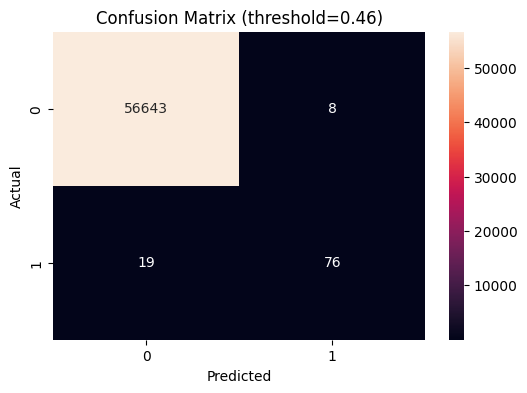

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix (threshold={threshold})"
)

plt.show()

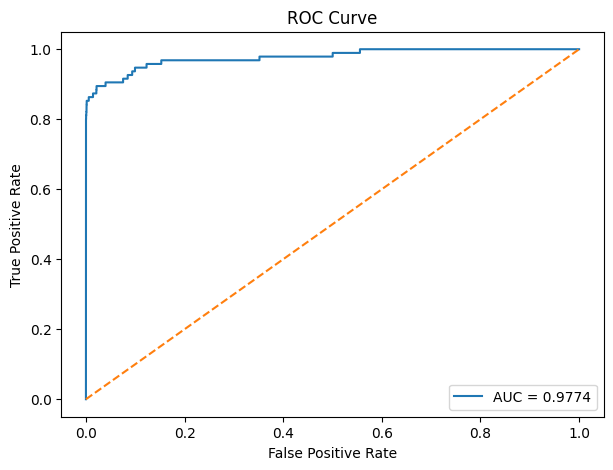

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

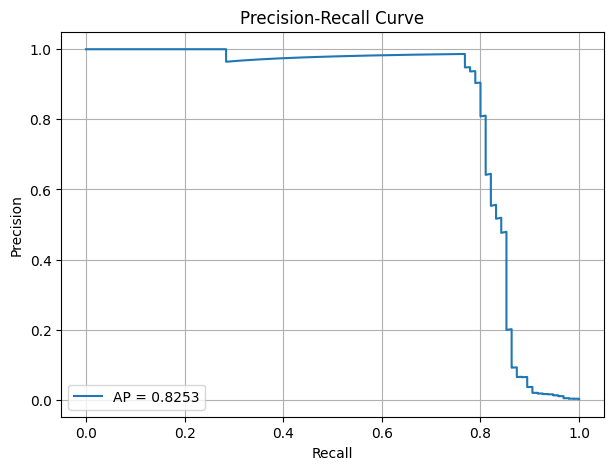

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)


ap = average_precision_score(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap:.4f}"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)


plt.legend()

plt.grid()

plt.show()